## TSP basics

In [1]:
import numpy as np
from scipy.spatial import distance

In [2]:
#########################################
#          Generate Nodes_coord         #
#########################################
def aggr_node2edge(node_feats):
    aggr_edge_feats = list()
    incremental_idx = 0
    n_nodes = node_feats.shape[0]
    for j in range(n_nodes):
        for k in range(j):
            aggr_edge_feats.append(np.hstack((node_feats[j], node_feats[k])))
            incremental_idx += 1
    # aggr_edge_feats = torch.FloatTensor(aggr_edge_feats)
    return aggr_edge_feats

def generate_nodes_coord(batch_size: int, n_nodes: int, kwargs):
    if kwargs["type"] == "uniform":
        return generate_uniform(
            batch_size, n_nodes, low=kwargs["low"], high=kwargs["high"]
        )
    elif kwargs["type"] == "cluster":
        return generate_cluster(
            batch_size=batch_size,
            n_nodes=n_nodes,
            num_clusters=kwargs["num_clusters"],
            cluster_std=kwargs["cluster_std"],
            center_low=kwargs["center_low"],
            center_high=kwargs["center_high"],
        )
    elif kwargs["type"] == "gaussian":
        return generate_gaussian(
            batch_size=batch_size,
            n_nodes=n_nodes,
            mean_x=kwargs["mean_x"],
            mean_y=kwargs["mean_y"],
            std=kwargs["gaussian_std"],
        )
    # elif kwargs["type"] == "cluster_fixed_centers":
    #     return generate_cluster_fixed_centers(batch_size, n_nodes)
    else:
        raise NotImplementedError


def generate_uniform(batch_size: int, n_nodes: int, low: float, high: float):
    return np.random.uniform(low, high, (batch_size, n_nodes, 2))


def generate_gaussian(
    batch_size: int,
    n_nodes: int,
    mean_x: float = 0.0,
    mean_y: float = 0.0,
    std: float = 1.0,
):
    return np.random.normal(
        loc=[mean_x, mean_y], scale=std, size=(batch_size, n_nodes, 2)
    )


def generate_cluster(
    batch_size: int,
    n_nodes: int,
    num_clusters: int,
    cluster_std: float,
    center_low: float,
    center_high: float,
):
    nodes_coords = np.zeros([batch_size, n_nodes, 2])
    for i in range(batch_size):
        cluster_centers = np.random.uniform(center_low, center_high, (num_clusters, 2))
        cluster_points = []
        for center in cluster_centers:
            points = np.random.normal(
                loc=center, scale=cluster_std, size=(n_nodes // num_clusters, 2)
            )
            cluster_points.append(points)
        nodes_coords[i] = np.concatenate(cluster_points, axis=0)  # (5,  2) (5, 2)
    return nodes_coords


def generate_cluster_fixed_centers(batch_size: int, n_nodes: int):
    assert n_nodes in [100, 500]
    nodes_coords = np.zeros([batch_size, n_nodes, 2])
    for i in range(batch_size):
        num_clusters_axis = 2 if n_nodes == 100 else 5
        num_clusters = num_clusters_axis**2
        cluster_centers_axis = np.linspace(0, 1, num_clusters_axis * 2 + 1)[1::2]
        x, y = np.meshgrid(cluster_centers_axis, cluster_centers_axis)
        cluster_centers = [[x, y] for x, y in zip(x.flatten(), y.flatten())]
        scale = (
            1 / (num_clusters_axis * 3 * 3)
            if n_nodes == 100
            else 1 / (num_clusters_axis * 3 * 3)
        )
        cluster_points = []
        for center in cluster_centers:
            points = np.random.normal(
                loc=center, scale=scale, size=(n_nodes // num_clusters, 2)
            )
            cluster_points.append(points)
        nodes_coords[i] = np.concatenate(cluster_points, axis=0)
    return nodes_coords

## TSP trails

In [34]:
n_data = 3
n_feats = 50
n_nodes = 20
seed=2023
low, high = 0, 1
distance_factor = 10
kwargs = {"poly_deg":4, "noise_width":0.2, "type": "uniform", "low":low, "high": high, "distance_factor": distance_factor}

In [35]:
def poly_func(B, input):
    n_units = input.shape[-1]
    return (np.dot(input, B) / np.sqrt(n_units) + 3) ** deg / (3 ** (deg - 1))

distance_factor = kwargs["distance_factor"]
n_edges = int((n_nodes * (n_nodes - 1)) / 2)
deg, noise_width = kwargs["poly_deg"], kwargs["noise_width"]
# set seed
rnd = np.random.RandomState(seed)
# random coordinates
coords = generate_nodes_coord(n_data, n_nodes, kwargs)  # n_data, n_nodes, 2
# distance matrix
pairwise_dist = np.array(
    [
        distance.cdist(coords[idx], coords[idx], "euclidean")
        for idx in range(n_data)
    ]
)
busy_degree = np.abs(rnd.normal(1, 1, (1, n_edges)))
# random matrix parameter B
B = rnd.binomial(1, 0.5, (n_feats)) * rnd.uniform(-2, 2, (n_feats))
# feature vectors
edge_feats = rnd.normal(0, 1, (n_data, n_edges, n_feats))
time = np.zeros((n_data, n_edges))
node_feats = list()
for i in range(n_data):
    incremental_idx = 0
    for j in range(n_nodes):
        for k in range(j):
            # print( pairwise_dist[i, j, k] , busy_degree[0, incremental_idx])
            time[i, incremental_idx] = (
                pairwise_dist[i, j, k] * busy_degree[0, incremental_idx] * distance_factor
            )
            incremental_idx += 1
    # noise
    noise = rnd.uniform(1 - noise_width, 1 + noise_width, n_edges)
    poly_term = poly_func(B, edge_feats[i]).reshape(-1)  # B: (E,) x[i]:(E, d) # poly_term: d
    print("node: ", time[i][:10], "\nedge: ", poly_term[:10], "\n\n")
    time[i] += poly_term * noise
    node_feats.append(aggr_node2edge(coords[i]))
node_feats = np.array(node_feats)


node:  [4.87454615e+00 1.29597513e+00 3.31234414e-03 7.60738826e+00
 3.26693827e+00 6.14759804e-01 2.36270941e+01 9.15724306e+00
 5.25533620e+00 1.89358829e+00] 
edge:  [9.83699749 2.26323656 1.00162217 3.52730686 2.10289502 1.72736965
 0.04725054 2.34116619 3.06237339 1.20296272] 


node:  [1.80364455e+01 6.47045063e+00 3.46331884e-03 7.06132263e+00
 4.67401570e+00 5.55207666e-01 1.74088879e+01 2.19442410e+01
 9.77699382e+00 1.32686728e+01] 
edge:  [0.00823966 1.95332954 1.09075111 1.48838138 0.2705725  1.14191781
 5.74462264 1.83951332 0.03292356 3.76144422] 


node:  [5.07962399e+00 5.66302377e+00 1.82363623e-02 8.50711179e+00
 6.26452536e+00 5.81952239e-01 2.24586216e+01 1.23839739e+01
 7.51657438e+00 6.00754763e+00] 
edge:  [3.02260225 7.24161309 5.11517931 0.48870427 4.21350249 4.55904356
 2.38920885 2.78692141 0.35831316 3.51454397] 




In [18]:
time.shape

(3, 10)

In [19]:
time

array([[ 6.29084733,  2.29844247,  1.07651519,  4.53238329,  0.51006056,
         3.62911758, 10.74687131,  4.42168488,  2.5410382 ,  9.54340289],
       [ 3.40361013,  3.35263678,  0.71832063,  4.52241535,  0.9887997 ,
         3.02748642,  2.50336344,  6.39873426,  2.9120405 ,  2.86580417],
       [ 4.87762499,  1.25226138,  3.32399048,  3.98391474,  2.31133687,
         2.26970427, 10.30616914,  3.34578915,  4.64387251,  5.27691882]])

In [14]:
np.dot(B, x[0]).shape

(10,)

In [8]:
pairwise_dist.shape

(3, 5, 5)

In [10]:
i,j = 0,2
pairwise_dist[0,i,j], pairwise_dist[0,j,i]

(0.544467079111186, 0.544467079111186)

In [12]:
B.shape

(10,)

In [13]:
B

array([-0.        ,  0.00552906, -0.42212579, -0.        , -0.        ,
       -0.        , -0.        , -1.27870688, -0.4360344 , -1.85740716])

In [6]:
noise = rnd.uniform(
        1 - noise_width, 1 + noise_width, n_edges
    )
noise

array([1.04180288, 1.07860639, 0.90623393, 0.98898054, 1.11428744,
       0.92093384, 0.872693  , 0.90414632, 0.99011939, 1.08148005])

In [11]:
noise = rnd.uniform(
        1 - noise_width, 1 + noise_width, n_edges
    )
noise

array([1.17617386, 0.81265373, 0.96146527, 1.15528541, 1.03460516,
       1.0917497 , 1.18236874, 1.08577979, 1.1587586 , 1.05379595])

## TSP gen function

In [26]:
def gendata(n_data, n_feats, n_nodes, seed=2023, **kwargs):
    def poly_func(B, input):
        n_units = input.shape[-1]
        return  (np.dot(B, input)/ np.sqrt(n_units) + 3 ) ** deg / (3 ** (deg - 1))

    n_edges = int((n_nodes * (n_nodes-1)) / 2)
    deg, noise_width = kwargs["deg"], kwargs["noise_width"]
    # set seed
    rnd = np.random.RandomState(seed)
    # random coordinates
    coords = generate_nodes_coord(n_data, n_nodes, kwargs) # n_data, n_nodes, 2
    # distance matrix
    pairwise_dist = np.array([distance.cdist(coords[idx], coords[idx], "euclidean") for idx in range(n_data)])
    busy_degree = np.abs(rnd.normal(1, 1, (n_data, n_edges)))
    # random matrix parameter B
    B = rnd.binomial(1, 0.5, (n_feats)) * rnd.uniform(-2, 2, (n_feats))
    # feature vectors
    x = rnd.normal(0, 1, (n_data, n_edges, n_feats))
    time = np.zeros((n_data, n_edges)) 
    for i in range(n_data):
        incremental_idx = 0
        for j in range(n_nodes):
            for k in range(j):
                time[i, incremental_idx] = pairwise_dist[i, j, k] * busy_degree[i, incremental_idx]
                incremental_idx += 1
        # noise
        noise = rnd.uniform(
            1 - noise_width, 1 + noise_width, n_edges
        ) 
        poly_term = poly_func(B, x[i]).reshape(-1) # B: (10,) x[i]:(10, 10)  
        time[i] += poly_term * noise
    return time, coords, x

In [34]:
kwargs1 = {"deg":2, "noise_width":0.2, "type": "uniform", "low": 0, "high": 1}
time, node_feats, edge_feats = gendata(n_data, n_feats, n_nodes, 2023, **kwargs1)
time, node_feats[0], edge_feats[0]

(array([[ 5.74799804,  2.48001512,  1.07523984,  4.65387872,  0.72589034,
          3.56523573,  9.70609674,  3.82435928,  1.79391374,  9.5276408 ],
        [ 3.37453783,  3.37975524,  0.7154919 ,  4.3887546 ,  0.98537506,
          2.77143944,  2.56420187,  6.55597319,  2.77427548,  3.19031633],
        [ 4.85855641,  1.276325  ,  3.5182574 ,  3.95122871,  1.97816965,
          3.00452163, 10.74831024,  2.73165598,  4.56795514,  5.16576701]]),
 array([[0.43584977, 0.85598813],
        [0.28442878, 0.35002118],
        [0.56360826, 0.42835898],
        [0.77034963, 0.25359935],
        [0.3346513 , 0.24512342]]),
 array([[-1.08776235e+00, -1.78707947e+00,  3.40618788e-01,
         -1.25350135e+00,  3.70787945e-01,  4.55253760e-01,
         -2.28372012e+00, -8.22003115e-04,  2.39887598e+00,
         -2.58310486e+00],
        [ 1.31100884e+00, -1.57947751e+00, -8.40682611e-01,
         -1.65509399e-01, -2.06841038e+00,  4.52738742e-01,
          5.11316257e-02, -2.38060748e-01, -2.080089

In [35]:
kwargs2 = {"deg":2, "noise_width":0.2, "type": "uniform", "low": 10, "high": 20}
time, node_feats, edge_feats = gendata(n_data, n_feats, n_nodes, 2023, **kwargs2)
time, node_feats[0], edge_feats[0]

(array([[18.28683166,  7.63219036,  1.08292097, 12.3021916 ,  3.7031719 ,
          3.70480479, 43.39900862, 11.04481351,  9.57397102, 23.20676374],
        [ 3.57885597,  6.27141089,  0.73564273,  4.97179241,  1.08344475,
          5.29068039,  7.92783906, 13.8272576 ,  6.0566404 , 14.81612543],
        [ 4.91538449,  2.17313438,  4.64137111, 10.20888371, 12.81323923,
          9.17869668, 11.50284847,  6.55011554, 10.03222167, 18.14240431]]),
 array([[10.82246362, 13.82708606],
        [18.44772251, 15.70718995],
        [18.49381948, 11.31131724],
        [17.45822301, 12.02643012],
        [19.4111413 , 18.62712681]]),
 array([[-1.08776235e+00, -1.78707947e+00,  3.40618788e-01,
         -1.25350135e+00,  3.70787945e-01,  4.55253760e-01,
         -2.28372012e+00, -8.22003115e-04,  2.39887598e+00,
         -2.58310486e+00],
        [ 1.31100884e+00, -1.57947751e+00, -8.40682611e-01,
         -1.65509399e-01, -2.06841038e+00,  4.52738742e-01,
          5.11316257e-02, -2.38060748e-01,

In [25]:
n_data = 5
n_feats = 10
n_nodes = 5
n_edges = int((n_nodes * (n_nodes-1)) / 2)
seed=2023
kwargs3 = {"deg":2, "noise_width":0.2, "type": "cluster", "num_clusters": 5,"cluster_std":0.05, "center_low":0, "center_high":10}
time, node_feats, edge_feats = gendata(n_data, n_feats, n_nodes, 2023, **kwargs3)
time, node_feats[0], edge_feats[0]

shape: (5, 2) (5, 2)
shape: (5, 2) (5, 2)
shape: (5, 2) (5, 2)
shape: (5, 2) (5, 2)
shape: (5, 2) (5, 2)


(array([[ 6.50445224,  6.408026  ,  0.59246287,  7.98454844, 10.474787  ,
          7.82910851, 20.32030458, 16.23227424,  6.69728666,  3.92246478],
        [ 2.67108833,  4.95037135,  3.51052451, 10.35447393,  3.55530109,
          5.51632457, 10.55990416, 12.39379825,  3.1745802 ,  8.91768634],
        [ 5.57477006,  4.73028222,  3.12098538,  5.9419176 , 12.70348104,
         10.25668168, 11.78789711, 12.06309658, 21.80970851,  5.02279492],
        [ 8.81293361,  3.18115534,  3.69553753,  5.04345448, 43.48698159,
         22.1173001 , 18.8352167 ,  4.17463609,  4.3427531 , 17.2685856 ],
        [12.20971743,  3.54168958,  4.43892201,  6.39329405,  1.67329538,
         11.64721704,  6.26151107,  3.71918549,  5.59244866, 10.60799576]]),
 array([[4.36580104, 1.50969095],
        [0.68659234, 1.08593047],
        [6.42659653, 7.77669122],
        [4.29746921, 5.01851721],
        [3.91070035, 5.67722614]]),
 array([[-0.29180011,  0.02999245, -0.86840407,  0.60434626,  0.72855446,
       

In [9]:
kwargs4 = {"deg":2, "noise_width":0.2, "type": "gaussian", "mean_x":0, "mean_y":0, "gaussian_std": 0.3}
time, node_feats, edge_feats = gendata(n_data, n_feats, n_nodes, 2023, **kwargs4)
time, node_feats[0], edge_feats[0]

(array([[ 5.49409297,  2.40632715,  1.07587692,  4.22672614,  0.91220076,
          3.55161741, 10.09382557,  6.04049473,  1.90941207,  9.48690318],
        [ 3.36955766,  3.83097733,  0.70828134,  4.51055859,  0.96590152,
          3.03864888,  2.67435794,  5.87958924,  2.85997326,  3.14388956],
        [ 4.88126506,  1.04367858,  3.4953764 ,  4.28826886,  2.52603993,
          2.8839759 , 10.43756134,  2.11131006,  4.1364931 ,  5.50701546]]),
 array([[-0.14999427,  0.13277376],
        [-0.39685208,  0.42140949],
        [-0.24541289, -0.19066679],
        [-0.07143352, -0.20162955],
        [-0.22582924, -0.5885402 ]]),
 array([[-1.08776235e+00, -1.78707947e+00,  3.40618788e-01,
         -1.25350135e+00,  3.70787945e-01,  4.55253760e-01,
         -2.28372012e+00, -8.22003115e-04,  2.39887598e+00,
         -2.58310486e+00],
        [ 1.31100884e+00, -1.57947751e+00, -8.40682611e-01,
         -1.65509399e-01, -2.06841038e+00,  4.52738742e-01,
          5.11316257e-02, -2.38060748e-01,

In [27]:
node_feats.shape, edge_feats.shape

((5, 5, 2), (5, 10, 10))

## TSP solver

In [51]:
import elkai
import numpy as np

from openpto.method.Solvers.abcptoSolver import ptoSolver

class LKHSolver(ptoSolver):
    """ """

    def __init__(self, modelSense, n_nodes, **kwargs):
        super().__init__(modelSense)
        self.n_nodes = n_nodes
        self.nodes = list(range(n_nodes))
        self.edges = [(i, j) for i in self.nodes for j in self.nodes if i < j]

    @property
    def n_vars(self):
        return self.n_nodes ** 2
    @property
    def n_edges(self):
        return len(self.edges)
    
    def solve(self, Y):
        """ """
        distance_matrix = np.zeros((self.n_nodes, self.n_nodes))
        for idx, (i, j) in enumerate(self.edges):
            distance_matrix[i][j] = Y[idx]
            distance_matrix[j][i] = Y[idx]
        np.fill_diagonal(distance_matrix, np.inf)
        cities = elkai.DistanceMatrix(distance_matrix)
        tour = cities.solve_tsp()
        sol_array, sol_matrix = self.tour2matrix(self.n_nodes, tour)  # decode sol to matrix
        others = {"tour": tour, "sol_matrix": sol_matrix}
        return sol_array, None, others
    
    def tour2matrix(self, n_nodes, tour):
        sol_matrix = np.zeros((n_nodes, n_nodes))
        for idx in range(len(tour) - 1):
            u, v = tour[idx], tour[idx + 1]
            sol_matrix[u, v] = 1
        # sol_array = [sol_matrix[i, j] for i in range(n_nodes) for j in range(n_nodes) if i < j]
        sol_array = np.zeros(self.n_edges, dtype=np.uint8)
        for k, (i, j) in enumerate(self.edges):
            if sol_matrix[i, j] > 1e-2 or sol_matrix[j, i] > 1e-2:
                sol_array[k] = 1
        return sol_array, sol_matrix


In [41]:
from collections import defaultdict

import gurobipy as gp  # pylint: disable=no-name-in-module
import numpy as np

from gurobipy import GRB  # pylint: disable=no-name-in-module

from openpto.method.Solvers.grb.grbSolver import optGrbSolver


# optimization model
class TSPGrbSolver(optGrbSolver):
    """
    Code is adopted by PyEPO. This class is optimization model for traveling salesman problem based on Gavish–Graves (GG) formulation.
    """

    def __init__(self, modelSense, n_nodes, **kwargs):
        super().__init__(modelSense)
        self.n_nodes = n_nodes
        # TSP nodes & edges
        self.nodes = list(range(n_nodes))
        self.edges = [(i, j) for i in self.nodes for j in self.nodes if i < j]
        self._model, self.z = self._getModel()
        # turn off output
        self._model.Params.outputFlag = 0

    @property
    def n_edges(self):
        return len(self.edges)

    def _getModel(
        self,
    ):
        """
        A method to build Gurobi model

        Returns:
            tuple: optimization model and variables
        """
        # ceate a model
        m = gp.Model("tsp")
        # varibles
        directed_edges = self.edges + [(j, i) for (i, j) in self.edges]
        z = m.addVars(directed_edges, name="z", vtype=GRB.BINARY)
        y = m.addVars(directed_edges, name="y")
        # sense
        assert self.modelSense == GRB.MINIMIZE
        m.modelSense = self.modelSense
        # constraints
        m.addConstrs(z.sum("*", j) == 1 for j in self.nodes)
        m.addConstrs(z.sum(i, "*") == 1 for i in self.nodes)
        m.addConstrs(
            y.sum(i, "*") - gp.quicksum(y[j, i] for j in self.nodes[1:] if j != i) == 1
            for i in self.nodes[1:]
        )
        m.addConstrs(y[i, j] <= (len(self.nodes) - 1) * z[i, j] for (i, j) in z if i != 0)
        return m, z

    def setObj(self, c):
        """
        A method to set objective function

        Args:
            c (list): cost vector
        """
        if len(c) != self.n_edges:
            raise ValueError("Size of cost vector cannot match vars.")
        obj = gp.quicksum(
            c[k] * (self.z[i, j] + self.z[j, i]) for k, (i, j) in enumerate(self.edges)
        )
        self._model.setObjective(obj)
        return

    def solve(self, y, **kwargs):
        """
        A method to solve model

        Returns:
            tuple: optimal solution (list) and objective value (float)
        """
        self.setObj(y)
        self._model.update()
        self._model.optimize()
        sol = np.zeros(self.n_edges, dtype=np.uint8)
        for k, (i, j) in enumerate(self.edges):
            if self.z[i, j].x > 1e-2 or self.z[j, i].x > 1e-2:
                sol[k] = 1
        others = {"sol_matrix": self.grbarr2arr(self.z)}
        return sol, self._model.objVal, others

    def grbarr2arr(self, grb_tensor):
        sol_array = np.zeros((self.n_nodes, self.n_nodes))
        for k, (i, j) in enumerate(self.edges):
            sol_array[i,j] = self.z[i,j].x
            sol_array[j,i] = self.z[j,i].x
        return sol_array

In [2]:
import pickle
prob = pickle.load(open('/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0-dev/saved_problems/TSP/TSP_13.pkl',"rb"))  
train_x, train_y, train_y_aux = prob.get_train_data()

In [4]:
train_x[0], train_y[0]

(tensor([[ 5.8805e-01,  1.2660e-01,  3.2199e-01,  8.9042e-01,  1.3248e+00,
           4.3929e-01, -5.5787e-01,  9.2708e-01, -6.0073e-01, -1.5197e+00,
           2.0973e+00,  8.9256e-01,  1.5965e+00, -6.3876e-01],
         [ 1.4134e-01,  4.6790e-01,  3.2199e-01,  8.9042e-01, -1.1330e+00,
           6.5660e-01,  5.9579e-01, -8.1112e-01, -3.0053e-01,  1.0084e+00,
          -1.0878e+00, -1.7871e+00,  3.4062e-01, -1.2535e+00],
         [ 1.4134e-01,  4.6790e-01,  5.8805e-01,  1.2660e-01,  3.7079e-01,
           4.5525e-01, -2.2837e+00, -8.2200e-04,  2.3989e+00, -2.5831e+00,
           1.3110e+00, -1.5795e+00, -8.4068e-01, -1.6551e-01],
         [ 2.2090e-02,  7.2727e-01,  3.2199e-01,  8.9042e-01, -2.0684e+00,
           4.5274e-01,  5.1132e-02, -2.3806e-01, -2.0801e-01,  4.0130e-01,
           1.8317e-01,  1.2358e+00, -2.9180e-01,  2.9992e-02],
         [ 2.2090e-02,  7.2727e-01,  5.8805e-01,  1.2660e-01, -8.6840e-01,
           6.0435e-01,  7.2855e-01,  1.3648e+00,  1.3427e+00, -1.4567e+00

In [9]:
train_y[0]

tensor([[5.7359],
        [3.1619],
        [2.6373],
        [3.0529],
        [6.2199],
        [3.3459],
        [4.2424],
        [4.5638],
        [3.6367],
        [3.4886]])

In [52]:
lkh = LKHSolver(modelSense=GRB.MINIMIZE, n_nodes=5)
grb = TSPGrbSolver(modelSense=GRB.MINIMIZE, n_nodes=5)

In [53]:
lkh.solve(train_y[0])

(array([0, 1, 1, 0, 0, 1, 1, 0, 1, 0], dtype=uint8),
 None,
 {'tour': [0, 2, 4, 1, 3, 0],
  'sol_matrix': array([[0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.],
         [1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.]])})

In [43]:
grb.solve(train_y[0])

(array([0, 1, 1, 0, 0, 1, 1, 0, 1, 0], dtype=uint8),
 17.024160146713257,
 {'sol_matrix': array([[ 0., -0.,  1., -0., -0.],
         [ 0.,  0.,  0.,  1.,  0.],
         [-0.,  0.,  0., -0.,  1.],
         [ 1., -0., -0.,  0., -0.],
         [-0.,  1., -0., -0.,  0.]])})

## TSP problem instance

In [36]:
import pickle
prob = pickle.load(open("../.././saved_problems/TSP/TSP_12.pkl", "rb"))

In [38]:
prob.ver0_others["coords"].shape

(400, 20, 2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_nodes(node_coordinates):
    x = node_coordinates[:, 0]
    y = node_coordinates[:, 1]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='b', label='Nodes')
    plt.title('Node Graph')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid(True)
    plt.show()


In [16]:
x_train, y_train, _ = prob.get_train_data(train_mode = "iid")

In [18]:
x_train[0]

tensor([[ 0.1108,  0.3924,  0.1215,  ...,  0.2295,  0.4170, -0.7121],
        [ 0.0407,  0.0336,  0.1215,  ..., -2.3566,  1.0766, -0.2814],
        [ 0.0407,  0.0336,  0.1108,  ...,  1.3991, -0.5206, -0.8858],
        ...,
        [ 0.2213,  0.0961,  0.9209,  ..., -1.8881,  0.5976, -0.6940],
        [ 0.2213,  0.0961,  0.9080,  ...,  0.2945, -0.1066, -1.4876],
        [ 0.2213,  0.0961,  0.2950,  ..., -1.3109,  1.5560, -0.4228]])

In [22]:
y_train[0].flatten()

tensor([11.6854,  2.3730,  0.9745,  4.1288,  2.6359,  1.5454,  1.4434,  3.1701,
         3.0186,  2.8514,  6.5941,  3.4732,  2.6332,  2.3452,  5.2635, 11.8914,
         3.8526,  7.0739,  1.9651,  2.6093, 15.8097,  6.9052,  3.7149,  1.5408,
         2.2596,  6.1667,  5.3222,  8.2644,  1.1773,  5.2431,  0.4627,  3.9228,
         3.2265,  2.1699,  8.5729,  1.9537,  2.0632,  5.5021, 16.7449,  3.9184,
         4.5116,  2.8091,  7.0701,  3.4293, 18.5297,  1.6762,  6.2555,  6.8670,
         1.3377,  2.2575, 11.7804,  3.8812,  6.3651,  2.7853,  9.9790,  0.7579,
         6.0735,  3.0982,  5.3915, 14.5110,  1.7123,  3.3069,  8.1737,  3.8093,
         0.8473,  3.2313,  3.0222,  7.3734,  1.3762,  6.3154,  2.7928,  2.1249,
         4.2079,  2.0775,  1.6302,  7.2712,  8.0213,  2.6756,  8.4466,  4.1639,
        13.2075,  9.5948,  3.8479,  5.3013,  3.2731,  2.3776,  2.4618,  4.7539,
         0.8820,  5.3892,  5.0511,  3.7076,  1.0069, 11.0776,  0.6951,  6.0850,
         1.3873,  1.0493,  4.3720,  2.07

## TSP with different distributions

### explosion

In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
def generate_explosion_pattern_with_parameters(n_points, center=(0, 0), min_radius=1.0, max_radius=5.0):
    """
    Generate an 'explosion' pattern of points with a void in the center.
    
    Parameters:
    n_points: int
        The number of points to generate.
    center: tuple
        The (x, y) coordinates of the center of the explosion.
    min_radius: float
        The minimum radius from the center to start generating points.
    max_radius: float
        The maximum radius from the center for generating points.
        
    Returns:
    x, y: np.ndarray
        The x and y coordinates of the points in the pattern.
    """
    # Angles are uniformly distributed between 0 and 2pi
    angles = np.random.uniform(0, 2 * np.pi, n_points)
    
    # Radii are distributed between the min_radius and max_radius
    # We use a distribution that favors points closer to the min_radius
    radii = np.random.exponential(scale=(max_radius - min_radius) / 2, size=n_points) + min_radius
    radii = np.clip(radii, min_radius, max_radius)  # Ensure radii are within the specified range
    
    # Convert polar coordinates to Cartesian coordinates
    x = center[0] + radii * np.cos(angles)
    y = center[1] + radii * np.sin(angles)
    
    return x, y


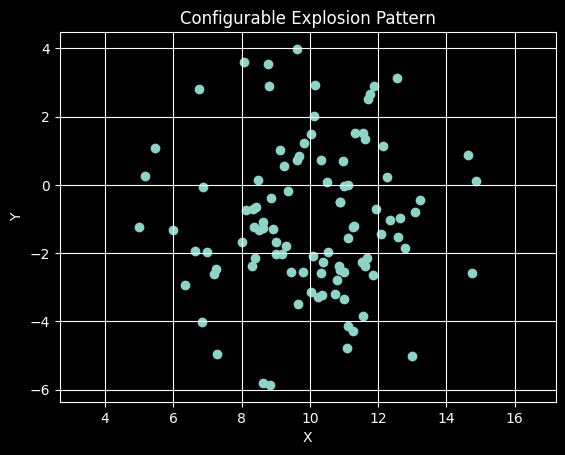

In [29]:
# Configurable parameters
n_points = 100
center = (10, -1)  # Center of the explosion
min_radius = 1.0  # Minimum radius, creating a void in the center
max_radius = 5.0  # Maximum radius of the explosion

# Generate points with the specified parameters
x, y = generate_explosion_pattern_with_parameters(n_points, center, min_radius, max_radius)

# Plotting the points to visualize the 'explosion' pattern with a central void
plt.scatter(x, y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Configurable Explosion Pattern')
plt.axis('equal')  # Equal scaling of the axes
plt.grid(True)
plt.show()